In [88]:
import numpy as np
import math
import matplotlib.pyplot as plt
import re
import json
import pickle
from collections import Counter

In [89]:
class Config:

    num_layers = 1000
    d_model = 10000000
    d_ff = 76000000
    num_heads = 4
    max_seq_len = 256
    vocab_size = 8_000
    lr = 3e-4
    
    
    @classmethod
    def neuron_count(cls):
        return cls.num_layers *(cls.d_model+cls.d_ff)

    @classmethod
    def show(cls):
        n= cls.neuron_count()
        print(f"\n{'/'*40}")
        print(f"- layer      { cls.num_layers:>12}")
        print(f"- d_ff       {cls.d_ff:>12}")
        print(f"- d_model      {cls.d_model:>12}")
        print(f"- heads      {cls.num_heads:>12}")
        print(f"- neurons    {n:>12,}   (target 86 B)")
        print(f"- coverage   {n / 86e9 * 100:>11.2f}%")
        print(f"{'/'*40}") 
        

In [90]:
Config.show()


////////////////////////////////////////
- layer              1000
- d_ff           76000000
- d_model          10000000
- heads                 4
- neurons    86,000,000,000   (target 86 B)
- coverage        100.00%
////////////////////////////////////////


In [91]:
print("Neurons are:",Config.neuron_count())
# 1000*(76000000+10000000)


Neurons are: 86000000000


*Math Utils* 

In [ ]:
def softmax(x,axis = -1):
    e = np.exp(x-x.max(axis = axis,keepdims = True))
    return e/(e.sum(axis= axis,keepdims = True)+1e-9) # softmax = e/sum(e) + h

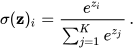 *softmax f(X)*

In [99]:
softmax(np.array([10,100]))

array([8.19401262e-40, 9.99999999e-01])

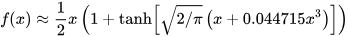 *Guassian error linear unit*

In [101]:
def gelu(x):
    c = math.sqrt(2.0/math.pi)
    return 0.5*x*(1.0+np.tanh(c*(x+0.044715*x**3)))

[-5 -4 -3 -2 -1  0  1  2  3  4] [-2.29179620e-07 -7.02459482e-05 -3.63739208e-03 -4.54023059e-02
 -1.58808009e-01  0.00000000e+00  8.41191991e-01  1.95459769e+00
  2.99636261e+00  3.99992975e+00]


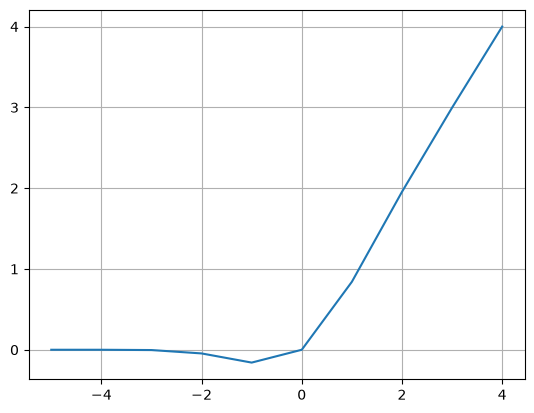

In [126]:
x = np.arange(-5,5,1)
y = gelu(x)
plt.plot(x,y)
plt.grid()
print(x[:10],y[:10])